# Demo 1: Supercritical Pitchfork Bifurcation

In this tutorial, we demonstrate how to use **`bifurx`** to:
1. Define a 1D equilibrium problem with a supercritical pitchfork bifurcation using JAX.
2. Track the trivial branch $u = 0$ using Keller pseudo-arclength continuation.
3. Automatically detect the simple **Branch Point (BP)** at $p = 0$.
4. Apply exact branch switching via the **Algebraic Bifurcation Equation (ABE)** using nested directional derivatives (`jax.jvp`).
5. Trace the non-trivial branches $u = \pm\sqrt{p}$ and verify stability.
6. Plot the complete bifurcation diagram.

---

## 1. Mathematical Background

The normal form of a supercritical pitchfork bifurcation is given by:

$$\dot{u} = F(u, p) = p u - u^3 = 0, \quad u \in \mathbb{R}, \quad p \in \mathbb{R}$$

### Equilibrium Solutions
1. **Trivial Branch**: $u(p) = 0$ exists for all parameter values $p \in \mathbb{R}$.
2. **Non-trivial Branches**: For $p > 0$, factoring $u(p - u^2) = 0$ yields two symmetric branches:
   $$u(p) = \pm\sqrt{p}$$

### Linear Stability Analysis
The Jacobian (derivative with respect to state $u$) is:

$$J_u(u, p) = \frac{\partial F}{\partial u} = p - 3 u^2$$

- **Along the Trivial Branch ($u = 0$)**:
  $$J_u(0, p) = p$$
  - For $p < 0$: $J_u < 0 \implies$ **linearly stable**.
  - For $p > 0$: $J_u > 0 \implies$ **linearly unstable**.
  - At $p = 0$: $J_u(0, 0) = 0$ and $J_p(0, 0) = 0 \in \text{Range}(J_u)$, defining a **simple Branch Point (BP)**.

- **Along the Non-trivial Branches ($u^2 = p$)**:
  $$J_u(\pm\sqrt{p}, p) = p - 3p = -2p < 0 \quad (\text{for } p > 0)$$
  Both emergent branches are **linearly stable**.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bifurx import (
    BifurcationProblem,
    continuation,
    plot_diagram,
    switch_branch,
)

# Enable 64-bit precision for high-accuracy numerical continuation
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.11.1


## 2. Defining the Problem in JAX

We formulate $F(u, p) = p u - u^3$ as a `BifurcationProblem`. `bifurx` automatically computes exact Jacobians $\nabla_u F$ and $\nabla_p F$ using `jax.jacobian`.


In [2]:
def f_pitchfork(u: jnp.ndarray, p: float) -> jnp.ndarray:
    x = u[0]
    return jnp.array([p * x - x**3])


prob = BifurcationProblem(f_pitchfork, u0=[0.0], p0=-0.5)

print(f"Problem dimension n = {prob.dim}")
print(f"Residual at (u0, p0):    F = {prob.residual(prob.u0, prob.p0)}")
print(f"State Jacobian at (u0): J_u = {float(prob.jacobian_u(prob.u0, prob.p0)[0, 0]):.4f}")
print(f"Param Jacobian at (p0): J_p = {float(prob.jacobian_p(prob.u0, prob.p0)[0]):.4f}")

Problem dimension n = 1
Residual at (u0, p0):    F = [-0.]


State Jacobian at (u0): J_u = -0.5000


Param Jacobian at (p0): J_p = 0.0000


## 3. Continuation along the Trivial Branch

Starting from $p_0 = -0.5, u_0 = 0.0$, we run Keller pseudo-arclength continuation toward positive $p$.


In [3]:
res_trivial = continuation(
    problem=prob,
    ds=0.04,
    max_steps=35,
    param_bounds=(-0.6, 0.6),
    branch_name="Trivial Branch (u=0)",
)

print(f"Continuation terminated after {res_trivial.num_points} steps.")
print(f"Parameter p spans [{min(res_trivial.p):.3f}, {max(res_trivial.p):.3f}]")

Continuation terminated after 7 steps.
Parameter p spans [-0.500, 1.100]


## 4. Automatic Detection of the Branch Point (BP)

During continuation, `bifurx` monitors the determinant of the Jacobian $\det(\nabla_u F)$. When it crosses zero, the bisection root finder isolates the precise branch point.


In [4]:
bps = res_trivial.get_bifurcations("BP")
assert len(bps) >= 1, "Expected at least one BP detected!"
bp0 = bps[0]

print("=== Detected Branch Point (BP) ===")
print(f"  Type:        {bp0.bif_type}")
print(f"  Parameter p: {bp0.p:.6e}  (exact analytical: 0.0)")
print(f"  State u:     {float(bp0.u[0]):.6e}  (exact analytical: 0.0)")
print(f"  Step index:  {bp0.step}")
print(f"  Tangent tau: {np.asarray(bp0.tangent)}")

=== Detected Branch Point (BP) ===
  Type:        BP
  Parameter p: 0.000000e+00  (exact analytical: 0.0)
  State u:     0.000000e+00  (exact analytical: 0.0)
  Step index:  4
  Tangent tau: [0. 1.]


## 5. Branch Switching via Algebraic Bifurcation Equation

At the branch point, the Algebraic Bifurcation Equation (ABE) solves for the secondary tangent direction using directional second derivatives evaluated via nested `jax.jvp`.

We call `switch_branch` to switch onto:
1. The **Upper Branch** ($u = +\sqrt{p}$) with `branch_direction=+1.0`
2. The **Lower Branch** ($u = -\sqrt{p}$) with `branch_direction=-1.0`


In [5]:
# Switch to Upper Branch (+u)
u_up, p_up, tau_up = switch_branch(prob, bp0.u, bp0.p, bp0.tangent, ds=0.04, branch_direction=1.0)
res_up = continuation(
    problem=prob,
    u0=u_up,
    p0=p_up,
    initial_tangent=tau_up,
    ds=0.03,
    max_steps=30,
    param_bounds=(-0.1, 0.6),
    branch_name="Upper Branch (+u)",
)

# Switch to Lower Branch (-u)
u_dn, p_dn, tau_dn = switch_branch(prob, bp0.u, bp0.p, bp0.tangent, ds=0.04, branch_direction=-1.0)
res_dn = continuation(
    problem=prob,
    u0=u_dn,
    p0=p_dn,
    initial_tangent=tau_dn,
    ds=0.03,
    max_steps=30,
    param_bounds=(-0.1, 0.6),
    branch_name="Lower Branch (-u)",
)

print(f"Upper branch traced: {res_up.num_points} points.")
print(f"Lower branch traced: {res_dn.num_points} points.")

Upper branch traced: 7 points.
Lower branch traced: 7 points.


## 6. Analytical Verification

We verify that the numerical solutions along the secondary branches satisfy $u^2 = p$:


In [6]:
# Upper branch error
p_up_arr = np.asarray(res_up.p)
u_up_arr = np.asarray(res_up.u)[:, 0]
err_up = np.max(np.abs(u_up_arr**2 - p_up_arr))

# Lower branch error
p_dn_arr = np.asarray(res_dn.p)
u_dn_arr = np.asarray(res_dn.u)[:, 0]
err_dn = np.max(np.abs(u_dn_arr**2 - p_dn_arr))

print(f"Max error |u^2 - p| on Upper Branch: {err_up:.2e}")
print(f"Max error |u^2 - p| on Lower Branch: {err_dn:.2e}")
assert err_up < 1e-3
assert err_dn < 1e-3

Max error |u^2 - p| on Upper Branch: 3.15e-08
Max error |u^2 - p| on Lower Branch: 3.15e-08


## 7. Bifurcation Diagram Visualization

We plot all three branches together using `plot_diagram`. Stable branches are rendered with solid lines, unstable branches with dashed lines, and the Branch Point is marked with a crimson square.


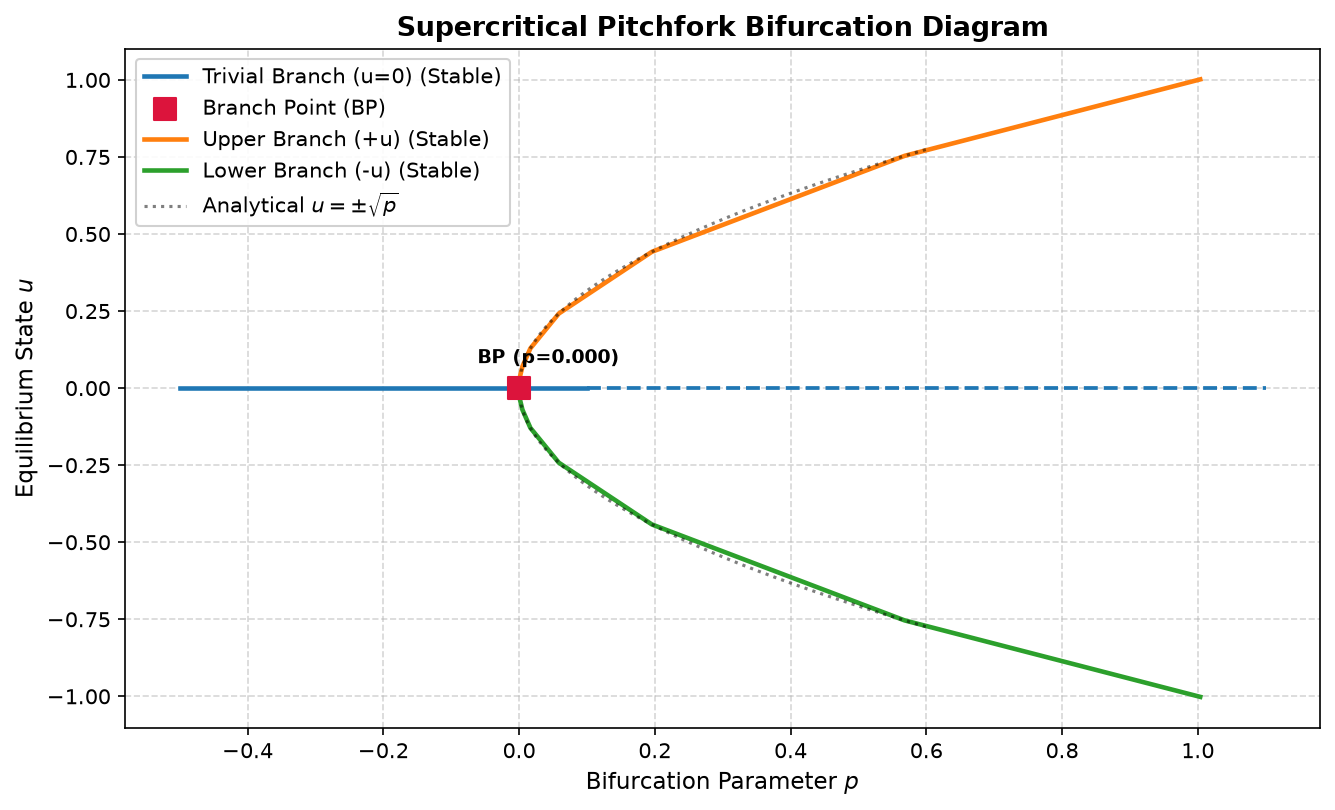

In [7]:
fig, ax = plot_diagram(
    [res_trivial, res_up, res_dn],
    state_index=0,
    title="Supercritical Pitchfork Bifurcation Diagram",
    xlabel="Bifurcation Parameter $p$",
    ylabel="Equilibrium State $u$",
    figsize=(9, 5.5),
)

# Overlay analytical curves for comparison
p_exact = np.linspace(0.0, 0.6, 200)
ax.plot(
    p_exact, np.sqrt(p_exact), "k:", linewidth=1.5, alpha=0.5, label=r"Analytical $u = \pm\sqrt{p}$"
)
ax.plot(p_exact, -np.sqrt(p_exact), "k:", linewidth=1.5, alpha=0.5)

ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()